In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Which tokens are we teaching the model to write?

Chapter 8 · Day 11

Use a fully inspectable symbolic template. It is not a Qwen tokenizer; it exposes the role/body/end distinction without any download.

Use the cycle: prediction → inspect mechanism → change one choice → interpret limits. Runnable reference answers follow each question. All computations use CPU; no model download or server is started.

In [2]:
from pathlib import Path
import sys
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/dongxi_llms").is_dir())
sys.path.insert(0, str(root / "src"))
import math, copy, json
import numpy as np
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "font.size": 11})
from dongxi_llms import evaluation_lab as ev
from dongxi_llms import instruction_data_lab as data
from dongxi_llms import sft_lab as sft
def show_flow(labels, focus):
    fig, ax = plt.subplots(figsize=(11, 1.9))
    for i, label in enumerate(labels):
        ax.text(i, .5, label, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=.45", fc="#dce9f5" if i == focus else "#f6f6f6", ec="#666"))
        if i: ax.annotate("", (i-.25,.5), (i-.75,.5), arrowprops=dict(arrowstyle="->",color="#555"))
    ax.set_xlim(-.6,len(labels)-.4); ax.set_ylim(0,1); ax.axis("off")
    ax.set_title("Schematic process: highlighted component is this lesson's focus")
    plt.show()


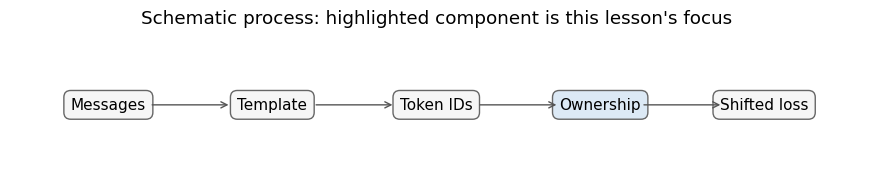

In [3]:
show_flow(["Messages","Template","Token IDs","Ownership","Shifted loss"], 3)

**Saved reference preview — rerun the preceding plot cell for current inputs.**

![01 roles templates and masks: reference plot 01](../figures/chapter-08/day-11-01_roles_templates_and_masks-01.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

## Predict 1

For BOS/SYSTEM/body/END/USER/body/END/ASSISTANT/body/END, identify the first assistant target and the position whose logit predicts it.

Pause and explain your reasoning before running the next cell.

### Reference answer and mechanism

The assistant body's token is the target; the immediately preceding assistant header produces its predicting logit. The mask attaches to the target, then shifts with labels.

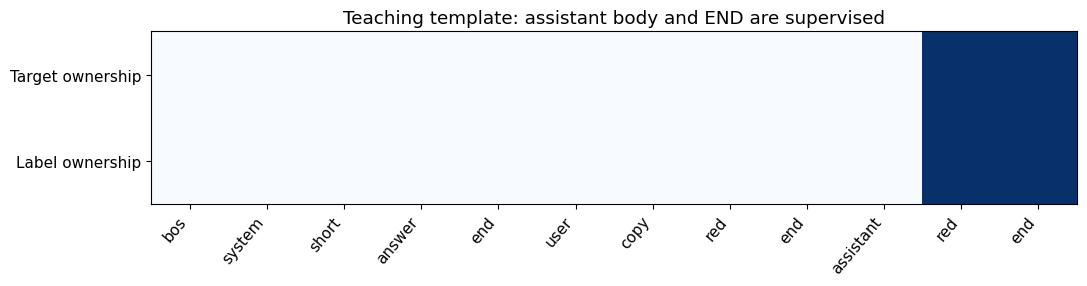

IDs: tensor([[ 1,  2, 16, 17,  5,  3, 10,  6,  5,  4,  6,  5]])
Labels: tensor([[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100,    6,    5]])


In [4]:
example = data.instruction_fixture()[0]
batch = data.collate([example])
tokens = [data.ID_TO_WORD[x] for x in example.ids]
values = np.array([example.supervised, [False]+[x!=-100 for x in batch["labels"][0,1:].tolist()]],dtype=int)
fig,ax = plt.subplots(figsize=(11,3))
ax.imshow(values,cmap="Blues",vmin=0,vmax=1,aspect="auto")
ax.set(xticks=np.arange(len(tokens)),xticklabels=tokens,yticks=[0,1],yticklabels=["Target ownership","Label ownership"],title="Teaching template: assistant body and END are supervised")
plt.xticks(rotation=50,ha="right"); plt.tight_layout(); plt.show()
print("IDs:",batch["input_ids"]); print("Labels:",batch["labels"])

**Saved reference preview — rerun the preceding plot cell for current inputs.**

![01 roles templates and masks: reference plot 02](../figures/chapter-08/day-11-01_roles_templates_and_masks-02.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

## Predict 2

Should END be supervised? What is lost if we remove that target?

Pause and explain your reasoning before running the next cell.

### Reference answer and mechanism

The intended assistant end marker teaches termination. Removing it retains the content target but removes direct corrective pressure to stop after the answer.

In [5]:
assert int((batch["labels"]!=-100).sum())==2
broken = batch["labels"].clone(); broken[0,-1] = -100
print("Correct count:",int((batch["labels"]!=-100).sum()),"missing-END count:",int((broken!=-100).sum()))

Correct count: 2 missing-END count: 1


## Predict 3

Why would applying the causal shift twice preserve valid tensor dimensions while silently changing the learning task?

Pause and explain your reasoning before running the next cell.

### Reference answer and mechanism

The labels remain integers of compatible shape, but now each logit predicts two positions ahead. Shape checks alone do not establish semantic alignment.

In [6]:
for t in range(len(tokens)-1):
    if batch["labels"][0,t+1] != -100:
        print("Logit at",tokens[t],"predicts",tokens[t+1])
assert tokens[-3]=="assistant" and tokens[-2]=="red"

Logit at assistant predicts red
Logit at red predicts end


## Reading the evidence

The figures are regenerated from the current lesson tensors or declared fixture. Axes and counts define the comparison. Change one control, rerun the relevant cell, and explain what changed in the mechanism. Separate a verified implementation property from a claim about a real language model.

Return to the corresponding chapter and worked solution for the complete argument.